
# 2 individuali uzduotis

Autorius: Augustas Kniška
LSP: 2312054
Variantas: Paprastas CNN; klases: Bee, Castle, Train
Uzdoties versija: 2026-03-17

In [1]:
%pip install -U scikit-learn seaborn torch-directml gradio

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# import sys
# !{sys.executable} -m pip install seaborn

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import transforms
from PIL import Image
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

dml_import_error = None
try:
    import torch_directml
except ImportError as e:
    torch_directml = None
    dml_import_error = str(e)

In [3]:
data_dir   = 'data'
classes    = ['Train', 'Bee', 'Castle']
num_epochs = 50
batch_size = 32
lr         = 5e-4  # Increased from 2e-4 since we now have BatchNorm
weight_decay = 1e-4
label_smoothing = 0.1
test_split = 0.2
val_split  = 0.1
seed       = 42
num_workers = 0
early_stopping_patience = 8  # Increased patience to allow more training
min_delta = 1e-4

if torch.cuda.is_available():
    device = torch.device('cuda')
    device_name = 'CUDA'
elif torch_directml is not None:
    device = torch_directml.device()
    device_name = 'DirectML'
else:
    device = torch.device('cpu')
    device_name = 'CPU'
    if dml_import_error is not None:
        print(f"[WARN] DirectML nepasiekiamas: {dml_import_error}")
        print("[INFO] Perkrauk branduoli po torch-directml diegimo.")

print(f"Naudojamas irenginys: {device_name} ({device})")

Naudojamas irenginys: DirectML (privateuseone:0)


In [4]:
class ImageFolderDataset(Dataset):
    """Nuskaito vaizdus is aplanko struktura: data/<class>/images/*.jpg"""

    def __init__(self, root_dir, classes, transform=None, cache=False):
        self.root_dir  = root_dir
        self.classes   = classes
        self.transform = transform
        self.cache     = cache
        self._cache    = {}
        self.samples   = []

        for class_idx, class_name in enumerate(classes):
            class_dir = os.path.join(root_dir, class_name.lower(), "images")
            if not os.path.isdir(class_dir):
                print(f"[WARN] Nerasta: {class_dir}")
                continue
            files = glob.glob(os.path.join(class_dir, "*.jpg"))
            for fp in files:
                self.samples.append((fp, class_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_path, label = self.samples[idx]
        if self.cache and file_path in self._cache:
            return self._cache[file_path], label
        image = Image.open(file_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        else:
            image = transforms.ToTensor()(image)
        if self.cache:
            self._cache[file_path] = image
        return image, label

## Duomenu paruosimas

- Duomenu rinkinys padalinamas i **mokymo** (80%) ir **testavimo** (20%) aibes naudojant `random_split`.
- Visi vaizdai suvienodinami i ta pati dydi ir normalizuojami.
- Mokymui naudojamos papildomos augmentacijos (apvertimas, spalvu jitter), testavimui - tik bazinis preprocessing.
- `cache=True` naudojamas testavimo aibei, nes ji perskaitoma tik viena karta.

In [5]:
img_size = 128
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

base_preprocess = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

# Stipresnes augmentacijos mokymui
train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

full_dataset = ImageFolderDataset(data_dir, classes, transform=None, cache=False)
print(f"Viso vaizdu: {len(full_dataset)}")

# Padalijimas
n_test  = int(len(full_dataset) * test_split)
n_train = len(full_dataset) - n_test
generator = torch.Generator().manual_seed(seed)
train_subset, test_subset = random_split(full_dataset, [n_train, n_test], generator=generator)
print(f"Mokymo+validacijos aibe: {n_train}, Testavimo aibe: {n_test}")

# Wrapper su skirtingomis transformacijomis
class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        file_path, label = self.subset.dataset.samples[self.subset.indices[idx]]
        image = Image.open(file_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

trainval_dataset = TransformSubset(train_subset, train_transform)
test_dataset     = TransformSubset(test_subset,  base_preprocess)

# Train/validation split viduje mokymo aibes
n_val = max(1, int(len(trainval_dataset) * val_split))
if n_val >= len(trainval_dataset):
    n_val = max(1, len(trainval_dataset) - 1)
n_train_final = len(trainval_dataset) - n_val
generator_val = torch.Generator().manual_seed(seed + 1)
train_dataset, val_dataset = random_split(trainval_dataset, [n_train_final, n_val], generator=generator_val)
print(f"Mokymo aibe: {len(train_dataset)}, Validacijos aibe: {len(val_dataset)}")

pin_memory = torch.cuda.is_available()

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=num_workers, pin_memory=pin_memory)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False,
                          num_workers=num_workers, pin_memory=pin_memory)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False,
                          num_workers=num_workers, pin_memory=pin_memory)

Viso vaizdu: 2246
Mokymo+validacijos aibe: 1797, Testavimo aibe: 449
Mokymo aibe: 1618, Validacijos aibe: 179


In [6]:
import hashlib
from collections import defaultdict

def build_hash_index(subset):
    """Build content-hash index for files in a Subset (exact-duplicate detection)."""
    hash_to_paths = defaultdict(list)
    for idx in subset.indices:
        file_path, _ = subset.dataset.samples[idx]
        with open(file_path, "rb") as f:
            file_hash = hashlib.sha1(f.read()).hexdigest()
        hash_to_paths[file_hash].append(file_path)
    return hash_to_paths

# 1) Sanity check: exact same file path in both splits (should be zero)
train_paths = {train_subset.dataset.samples[i][0] for i in train_subset.indices}
test_paths = {test_subset.dataset.samples[i][0] for i in test_subset.indices}
path_overlap = train_paths.intersection(test_paths)

# 2) Exact duplicate check by file content hash
train_hash_index = build_hash_index(train_subset)
test_hash_index = build_hash_index(test_subset)
shared_hashes = sorted(set(train_hash_index).intersection(test_hash_index))

print(f"Train images: {len(train_paths)}")
print(f"Test images:  {len(test_paths)}")
print(f"Same file path in both splits: {len(path_overlap)}")
print(f"Exact content duplicates across splits (hash overlap): {len(shared_hashes)}")

if shared_hashes:
    print("\nSample duplicate groups (up to 5):")
    for i, h in enumerate(shared_hashes[:5], start=1):
        print(f"\n[{i}] hash={h}")
        print(f"  train: {train_hash_index[h][0]}")
        print(f"  test : {test_hash_index[h][0]}")
else:
    print("\nNo exact content leakage detected between train and test splits.")

Train images: 1797
Test images:  449
Same file path in both splits: 0
Exact content duplicates across splits (hash overlap): 0

No exact content leakage detected between train and test splits.


## Modelis

- Naudojamas paprastas **CNN** modelis, mokomas nuo nulio (be pretrained svoriu).
- Modelis turi 3 konvoliucinius blokus su `ReLU` ir `MaxPool2d`.
- Paskutinis sluoksnis yra `Linear` su 3 isejimais (Train, Bee, Castle).
- Naudojamas `CrossEntropyLoss`, `Adam` optimizatorius ir `StepLR` tvarkarastis.

In [7]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

model = SimpleCNN(num_classes=len(classes)).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
 )

print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): D

In [8]:
train_losses = []
train_accs   = []
val_losses   = []
val_accs     = []

best_val_loss = float('inf')
best_state = None
patience_counter = 0

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / max(total, 1)
    train_acc = correct / max(total, 1)

    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_running_loss / max(val_total, 1)
    val_acc = val_correct / max(val_total, 1)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(
        f"Epoha [{epoch+1:2d}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}  "
        f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}"
    )

    if val_loss < (best_val_loss - min_delta):
        best_val_loss = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= early_stopping_patience:
            print(f"Early stopping ties {epoch+1} epocha.")
            break

if best_state is not None:
    model.load_state_dict(best_state)

print("Mokymas baigtas.")

c:\Users\Augustas\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\optim\adam.py:534: UserWarning: The operator 'aten::lerp.Scalar_out' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  torch._foreach_lerp_(device_exp_avgs, device_grads, 1 - beta1)


Epoha [ 1/50] Train Loss: 0.8176  Train Acc: 0.6922  Val Loss: 0.7689  Val Acc: 0.7374
Epoha [ 2/50] Train Loss: 0.7212  Train Acc: 0.7608  Val Loss: 0.7244  Val Acc: 0.7486
Epoha [ 3/50] Train Loss: 0.6770  Train Acc: 0.7849  Val Loss: 0.7137  Val Acc: 0.7765
Epoha [ 4/50] Train Loss: 0.6587  Train Acc: 0.8010  Val Loss: 0.6654  Val Acc: 0.7709
Epoha [ 5/50] Train Loss: 0.6337  Train Acc: 0.8109  Val Loss: 0.8219  Val Acc: 0.6983
Epoha [ 6/50] Train Loss: 0.6398  Train Acc: 0.8164  Val Loss: 0.7441  Val Acc: 0.7430
Epoha [ 7/50] Train Loss: 0.6299  Train Acc: 0.8158  Val Loss: 0.9127  Val Acc: 0.6983
Epoha [ 8/50] Train Loss: 0.6024  Train Acc: 0.8300  Val Loss: 0.6052  Val Acc: 0.8101
Epoha [ 9/50] Train Loss: 0.5890  Train Acc: 0.8344  Val Loss: 0.6401  Val Acc: 0.7989
Epoha [10/50] Train Loss: 0.5779  Train Acc: 0.8467  Val Loss: 0.6569  Val Acc: 0.8156
Epoha [11/50] Train Loss: 0.5773  Train Acc: 0.8511  Val Loss: 0.6234  Val Acc: 0.8101
Epoha [12/50] Train Loss: 0.5786  Train Acc

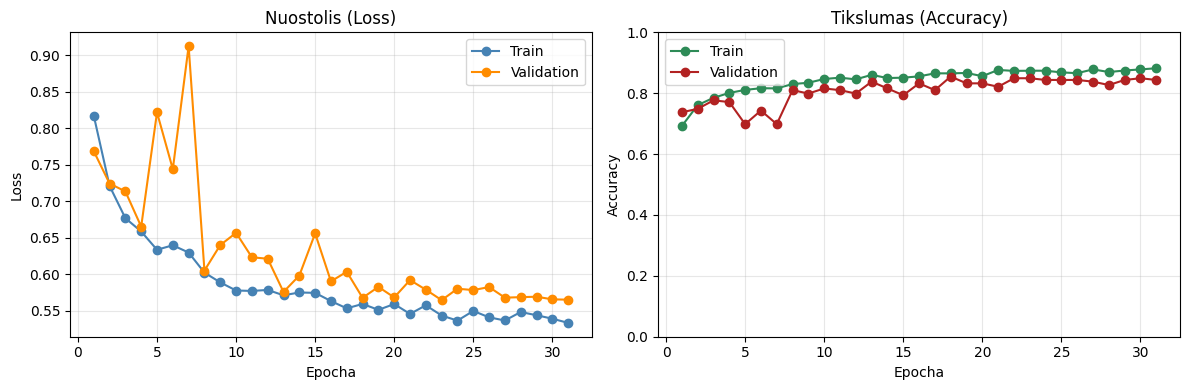

In [9]:
epochs = range(1, len(train_losses) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, train_losses, marker='o', color='steelblue', label='Train')
axes[0].plot(epochs, val_losses, marker='o', color='darkorange', label='Validation')
axes[0].set_title("Nuostolis (Loss)")
axes[0].set_xlabel("Epocha")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(epochs, train_accs, marker='o', color='seagreen', label='Train')
axes[1].plot(epochs, val_accs, marker='o', color='firebrick', label='Validation')
axes[1].set_title("Tikslumas (Accuracy)")
axes[1].set_xlabel("Epocha")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## Testavimas ir metrikos

Testavimo aibėje skaičiuojame:
- **Klasifikavimo matrica** (confusion matrix)
- **Tikslumas** (accuracy)
- **Precizija** (precision)
- **Atkūrimas** (recall)
- **F1** (F1-score)

Visos metrikos skaičiuojamos tiek kiekvienai klasei atskirai, tiek makro vidurkiu.

In [10]:
model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds   = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# --- Metrikos ---
accuracy  = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average=None, zero_division=0)
recall    = recall_score(all_labels, all_preds, average=None, zero_division=0)
f1        = f1_score(all_labels, all_preds, average=None, zero_division=0)

print(f"{'Klase':<10} {'Precizija':>10} {'Atkurimas':>10} {'F1':>8}")
print("-" * 42)
for i, cls in enumerate(classes):
    print(f"{cls:<10} {precision[i]:>10.4f} {recall[i]:>10.4f} {f1[i]:>8.4f}")

print("-" * 42)
print(f"{'Makro':<10} {precision.mean():>10.4f} {recall.mean():>10.4f} {f1.mean():>8.4f}")
print(f"\nBendras tikslumas: {accuracy:.4f}")

print("\nISAMUS PRANESIMAS:")
print(classification_report(all_labels, all_preds, target_names=classes, zero_division=0))

Klase       Precizija  Atkurimas       F1
------------------------------------------
Train          0.8895     0.8408   0.8645
Bee            0.8657     0.9590   0.9100
Castle         0.7907     0.6415   0.7083
------------------------------------------
Makro          0.8486     0.8138   0.8276

Bendras tikslumas: 0.8686

ISAMUS PRANESIMAS:
              precision    recall  f1-score   support

       Train       0.89      0.84      0.86       201
         Bee       0.87      0.96      0.91       195
      Castle       0.79      0.64      0.71        53

    accuracy                           0.87       449
   macro avg       0.85      0.81      0.83       449
weighted avg       0.87      0.87      0.87       449



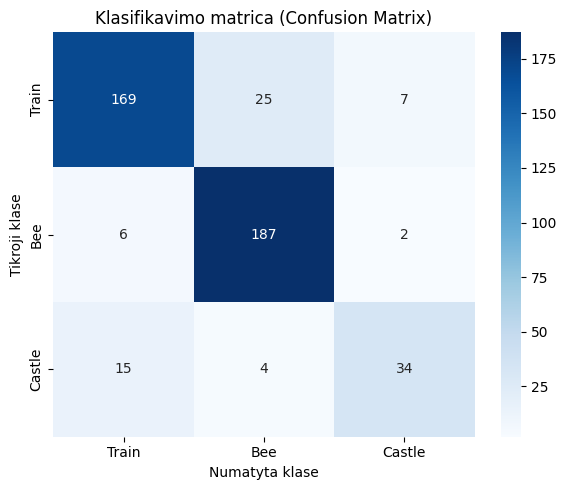

In [11]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes,
    ax=ax,
)
ax.set_xlabel("Numatyta klase")
ax.set_ylabel("Tikroji klase")
ax.set_title("Klasifikavimo matrica (Confusion Matrix)")
plt.tight_layout()
plt.show()

In [12]:
save_dir = 'models'
save_path = os.path.join(save_dir, 'simple_cnn_classifier.pth')
safe_path = os.path.join(save_dir, 'simple_cnn_classifier.safetensors')
os.makedirs(save_dir, exist_ok=True)

# DirectML aplinkoje torch.save gali mesti ModuleNotFoundError del torch/torchvision nesuderinamumo.
state_dict_cpu = {k: v.detach().cpu().contiguous() for k, v in model.state_dict().items()}

try:
    torch.save(state_dict_cpu, save_path)
    print(f"Modelis issaugotas: {save_path}")
except ModuleNotFoundError as e:
    if "torch.utils.serialization" in str(e):
        from safetensors.torch import save_file
        save_file(state_dict_cpu, safe_path)
        print("[WARN] torch.save nepavyko del torch.utils.serialization klaidos.")
        print(f"Modelis issaugotas alternatyviu formatu: {safe_path}")
    else:
        raise

Modelis issaugotas: models\simple_cnn_classifier.pth


## Vartotojo sasaja (Gradio)

Paleidus sia cele, atsidarys paprasta sasaja, kurioje galima ikelti paveiksliuka ir gauti klases prognoze.
Pries paleidziant, modelis turi buti apmokytas (11 cele).

In [13]:
try:
    gr = __import__("gradio")
except Exception as e:
    raise ImportError(
        "Gradio neirastas. Paleisk 2 cele (pip install) ir perkrauk branduoli."
    ) from e

def predict_one_image(img):
    if img is None:
        return "Ikelk paveiksliuka.", {}

    model.eval()
    x = base_preprocess(img.convert("RGB")).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()

    pred_idx = int(np.argmax(probs))
    pred_cls = classes[pred_idx]
    pred_conf = float(probs[pred_idx])

    label_scores = {classes[i]: float(probs[i]) for i in range(len(classes))}
    summary = f"Prognoze: {pred_cls} (pasitikejimas: {pred_conf:.2%})"
    return summary, label_scores

demo = gr.Interface(
    fn=predict_one_image,
    inputs=gr.Image(type="pil", label="Ikelk vaizda"),
    outputs=[
        gr.Textbox(label="Rezultatas"),
        gr.Label(label="Klasiu tikimybes", num_top_classes=3),
    ],
    title="Paprastas CNN vaizdu klasifikatorius",
    description="Klases: Train, Bee, Castle",
)

demo.launch(share=False)

c:\Users\Augustas\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
